# Multimode Intensity Shaping with Cascaded DOEs

This tutorial demonstrates intensity shaping of highly multimode light sources using
cascaded diffractive optical elements (DOEs). We optimize two phase-only DOEs embedded
in a glass substrate to transform 105 Laguerre-Gaussian modes into target intensity
distributions (square and ring). This approach reproduces the experimental configuration
from Ref. [2], where DOEs are integrated on the input and output faces of a glass element.

## Physical Context

Multimode light sources such as multimode fibers or filtered laser diodes exhibit
complex spatial intensity patterns due to the incoherent superposition of many modes.
Shaping these sources is challenging because each mode must be individually transformed
to contribute constructively to the desired target intensity. This problem is relevant
for laser materials processing, optical manipulation, and beam homogenization applications.

The approach demonstrated here builds on algorithmic methods for holographic beam shaping
of partially coherent light [1,2], using gradient-based optimization to find optimal
phase patterns that transform each mode appropriately. While the original work addressed
systems with thousands of modes (LP modes from step-index fibers), we use 105 Laguerre-Gaussian
modes here for computational efficiency. LG modes form a complete basis for graded-index fibers
and provide a good approximation for demonstrating the multimode shaping principle.

**References:**

[1]. N. Barré and A. Jesacher, "[Holographic beam shaping of partially coherent light](https://doi.org/10.1364/OL.444074),"
   Optics Letters **47**, 425-428 (2022).

[2]. N. Barré and A. Jesacher, "[Beam shaping of highly multimode sources with cascaded
   diffractive optical elements](https://doi.org/10.1016/j.procir.2022.08.151)," Procedia CIRP 111, 566-570 (2022).

In [1]:
using FluxOptics, Zygote, CairoMakie
using CUDA  # comment if you don't have CUDA

## Target Intensity Profiles

We define two target intensity distributions: a square flat-top and a ring. These
are constructed using smooth super-Gaussian functions to avoid sharp discontinuities
that would be difficult to achieve with phase-only modulation.

In [2]:
function square_intensity(c0::Real, n::Integer)
    function intensity(x, y)
        exp(-((x/c0)^n + (y/c0)^n))
    end
    intensity
end

function ring_intensity(r0::Real, w0::Real)
    function intensity(x, y)
        r = sqrt(x^2 + y^2)
        exp(-((r-r0)/w0)^2)
    end
    intensity
end

ring_intensity (generic function with 1 method)

## Multimode Source: Laguerre-Gaussian Basis

We create a highly multimode source by superposing 105 Laguerre-Gaussian modes.
LG modes form a complete basis for graded-index fibers and provide a tractable
representation for multimode beam shaping. The modes are generated with orders
satisfying 2p + |l| ≤ 13, where p is the radial index and l is the azimuthal index.

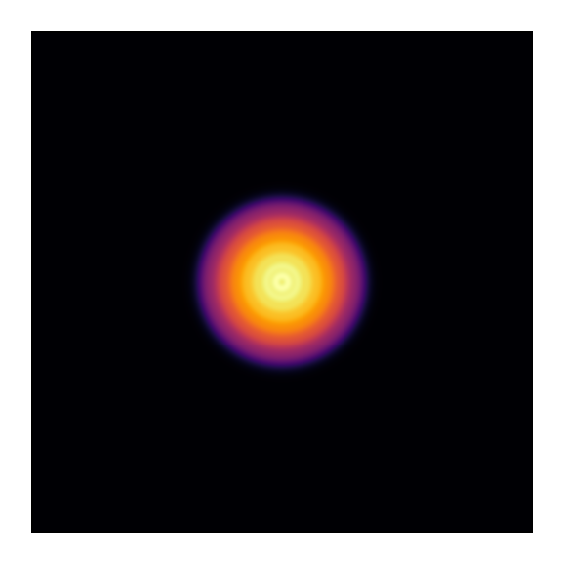

In [3]:
ns = (512, 512)
ds = (1.0, 1.0)
λ = 0.532
xv, yv = spatial_vectors(ns, ds);

w_in = 25.0
n_order = 13
lg_orders = [(p, l) for p in 0:(n_order ÷ 2) for l in (2 * p - n_order):(n_order - 2 * p)]
input_modes = stack(order -> LaguerreGaussian(w_in, order...)(xv, yv), lg_orders; dims = 3)
u0 = ScalarField(input_modes, ds, λ)
n_modes = size(u0, 3);

visualize(u0, intensity; colormap = :inferno, height = 250)

We have generated **105 Laguerre-Gaussian modes** spanning a wide range of
mode orders. Each mode is individually normalized, and their incoherent sum creates
a smooth cylindrical intensity pattern.

## Target Definitions

We define normalized target intensities for both the square and ring geometries.
The normalization ensures that the total power in the target matches the input
(n_modes since each input mode is normalized to unit power).

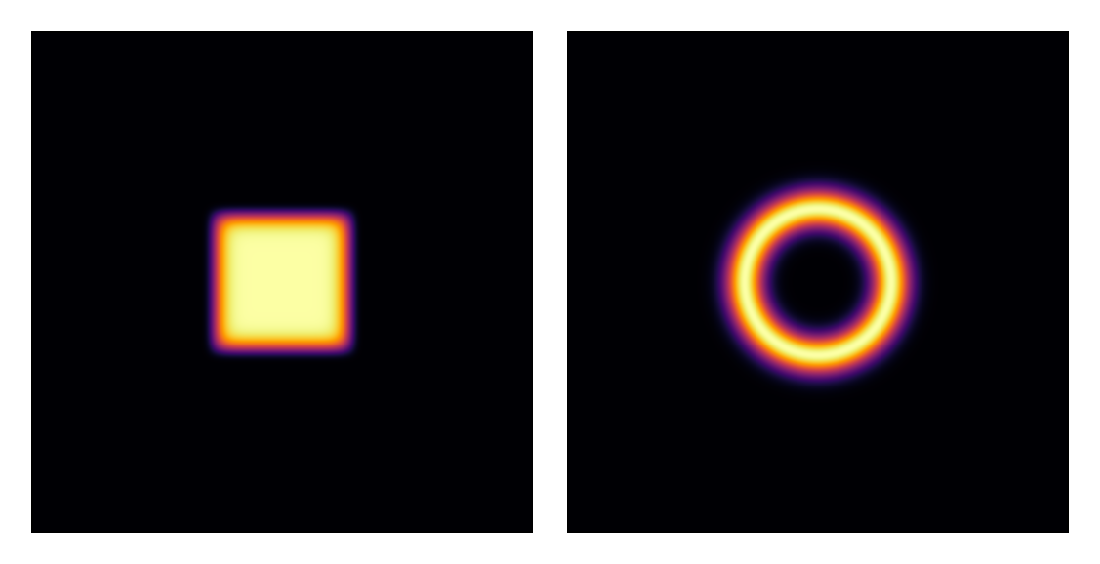

In [4]:
r0 = 75.0
c0 = 70.0
w0 = 20.0
n = 10
square_target = square_intensity(c0, n).(xv, yv')
ring_target = ring_intensity(r0, w0).(xv, yv')

square_target .*= n_modes / sum(square_target)
ring_target .*= n_modes / sum(ring_target);

visualize(hcat((square_target, ring_target)), real; colormap=:inferno, height=250)

The square target uses a super-Gaussian profile of side c₀=70 μm with exponent n=10 for smooth
edges, while the ring uses a radial Gaussian centered at radius r₀=75 μm with width w₀=20 μm.

## Optical System: Cascaded DOEs

The optical system reproduces the configuration from Ref. [2]: two phase-only DOEs
embedded in a glass substrate (n0=1.5), one on the input face and one on the output face.
The DOEs are separated by 600 μm of glass, followed by 300 μm of free-space propagation
to the target plane.

The glass thickness is larger than in the original article (which used ~2000 LP modes
from a step-index fiber) because with only 105 LG modes, the beam is less multimode
and diverges less rapidly. The increased propagation distance compensates for this,
providing sufficient mode mixing between the two DOEs.

This cascaded configuration provides two degrees of freedom for phase modulation,
significantly improving the quality of achievable intensity transformations compared
to a single DOE [2].

In [5]:
u0 = cu(u0)  # comment if you don't have CUDA
I_square = cu(square_target)  # comment if you don't have CUDA
I_ring = cu(ring_target)  # comment if you don't have CUDA

source = ScalarSource(u0);

z12 = 600.0  # Distance between DOEs (in glass)
z = 300.0    # Distance to target plane (in air)
n0 = 1.5     # Refractive index of glass

prop_glass = ASProp(u0, z12; n0 = n0)
prop_air = ASProp(u0, z)

doe1 = TeaDOE(u0, n0-1.0; trainable = true, buffered = true)
doe2 = TeaDOE(u0, n0-1.0; trainable = true, buffered = true)
pb = FieldProbe()

system = source |> doe1 |> prop_glass |> pb |> doe2 |> prop_air;

The `TeaDOE` components model thin diffractive elements with phase modulation
φ(x,y) = 2π Δn h(x,y) / λ, where h(x,y) is the height profile and Δn = n₀-1
is the refractive index contrast. A `FieldProbe` is inserted between the two DOEs
to monitor the intermediate intensity distribution, which helps verify that the
angular spectrum propagation remains physically reasonable throughout optimization.

### Initial output (no optimization)

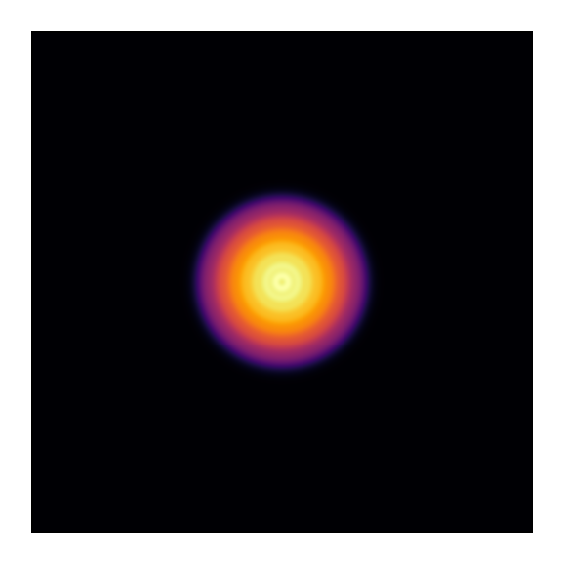

In [6]:
uf = system().out;

visualize(uf, intensity; colormap =:inferno, height=250)

## Optimization Setup

We use the FISTA algorithm with different regularization strategies for each target.
For both targets, heights are clamped to ensure fabrication feasibility.

In [7]:
square_metric = SquaredIntensityDifference((u0, I_square));
ring_metric = SquaredIntensityDifference((u0, I_ring));

loss_square(m) = sum(square_metric(m().out))
loss_ring(m) = sum(ring_metric(m().out));

## Square Target Optimization

For the square target, we use FISTA with TV-norm regularization to produce smooth,
fabricable DOE profiles. The TV-norm (Total Variation) penalizes sharp gradients in
the height profile, naturally enforcing smoothness. We also clamp heights to [0, 1.5] μm
to maintain reasonable fabrication constraints.

In [8]:
rule = ProxRule(Fista(30.0), ClampProx(0, 1.5) ∘ TVProx(3e-2))
opt_square = FluxOptics.setup(rule, system)
foreach(doe -> fill!(doe, 0), [doe1, doe2]);

Warm-up to compile kernels (first iteration is slower):

 35.863585 seconds (62.36 M allocations: 2.708 GiB, 5.24% gc time)


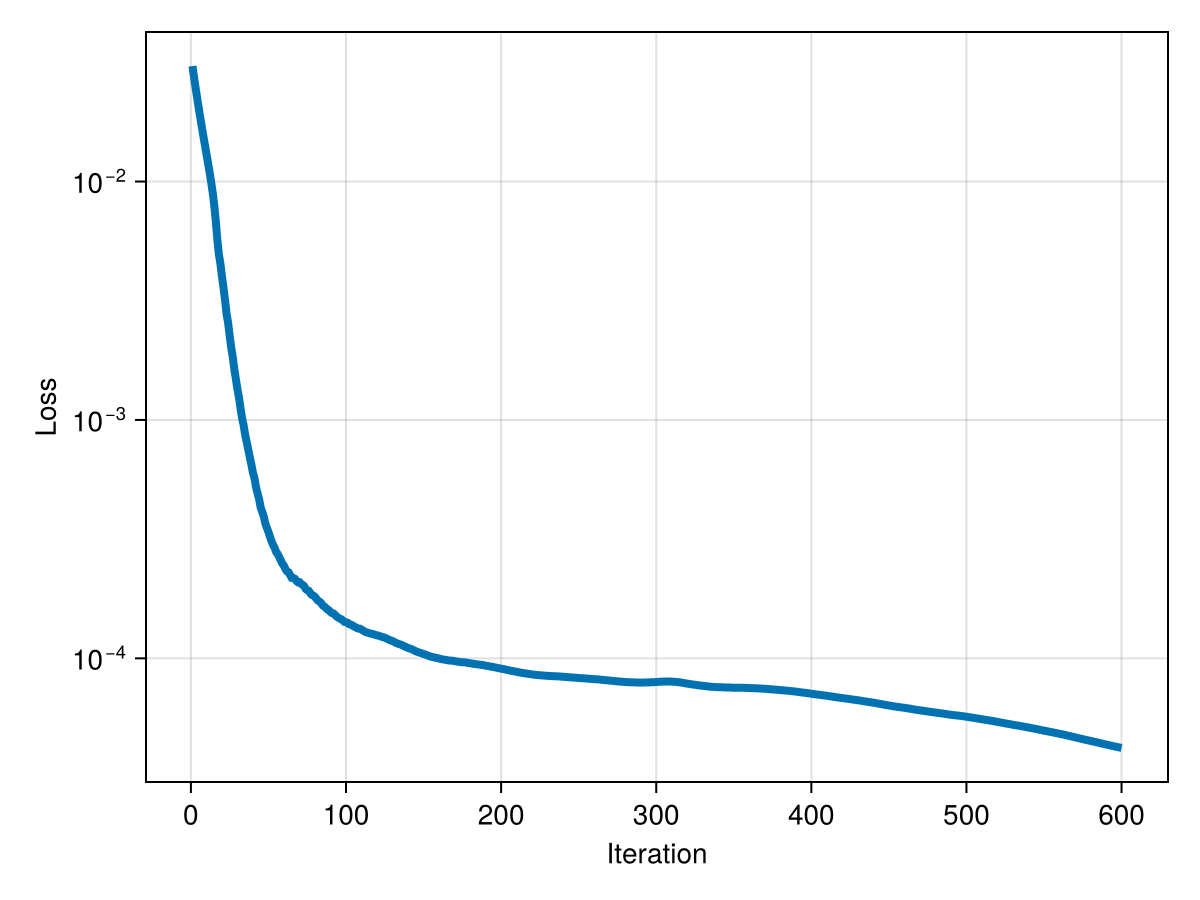

In [9]:
_, g = withgradient(loss_square, system);
FluxOptics.update!(opt_square, system, g[1]);

losses_square = []
@time for iter in 1:600
    val, grads = withgradient(loss_square, system)
    FluxOptics.update!(opt_square, system, grads[1])
    push!(losses_square, val)
end

fig_loss = Figure()
ax = Makie.Axis(fig_loss[1, 1], yscale = log10, xlabel = "Iteration", ylabel = "Loss")
lines!(ax, losses_square; linewidth = 4)
fig_loss

The loss decreases over 600 iterations. TV-norm regularization produces smooth DOE profiles
while maintaining good target fidelity. The loss curve suggests potential for further
improvement with additional iterations, though the current result already achieves good
square beam shaping.

### Optimized result for square target

We visualize both the intermediate field (between DOEs) and the final output to verify
that the propagation remains well-behaved throughout the system.

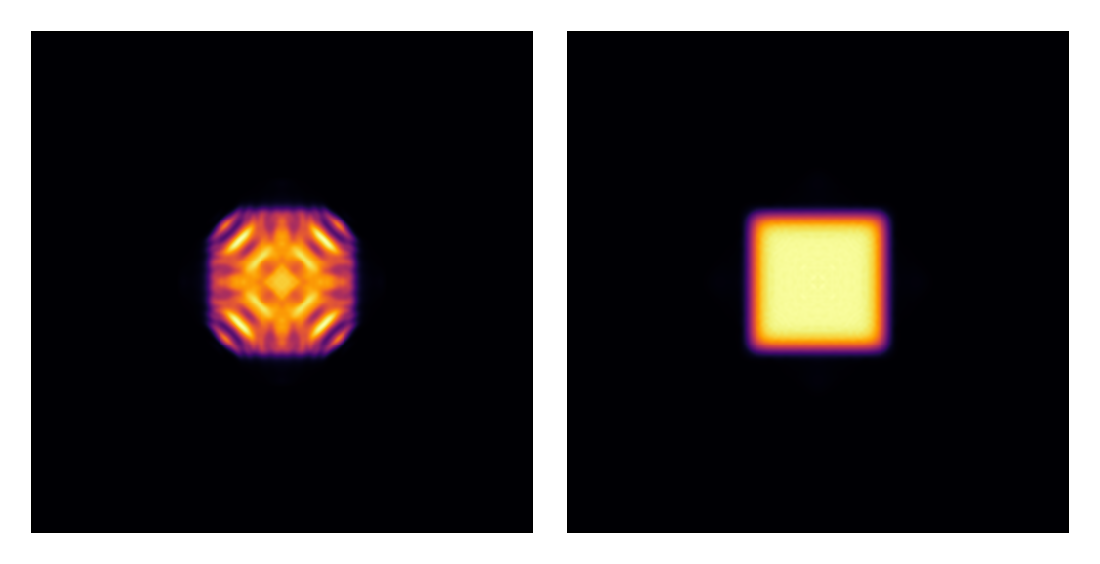

In [10]:
uf, probes = system()
u1 = probes[pb]

visualize(hcat((u1, uf)), intensity; colormap =:inferno, height=250)

### Optimized DOE height profiles

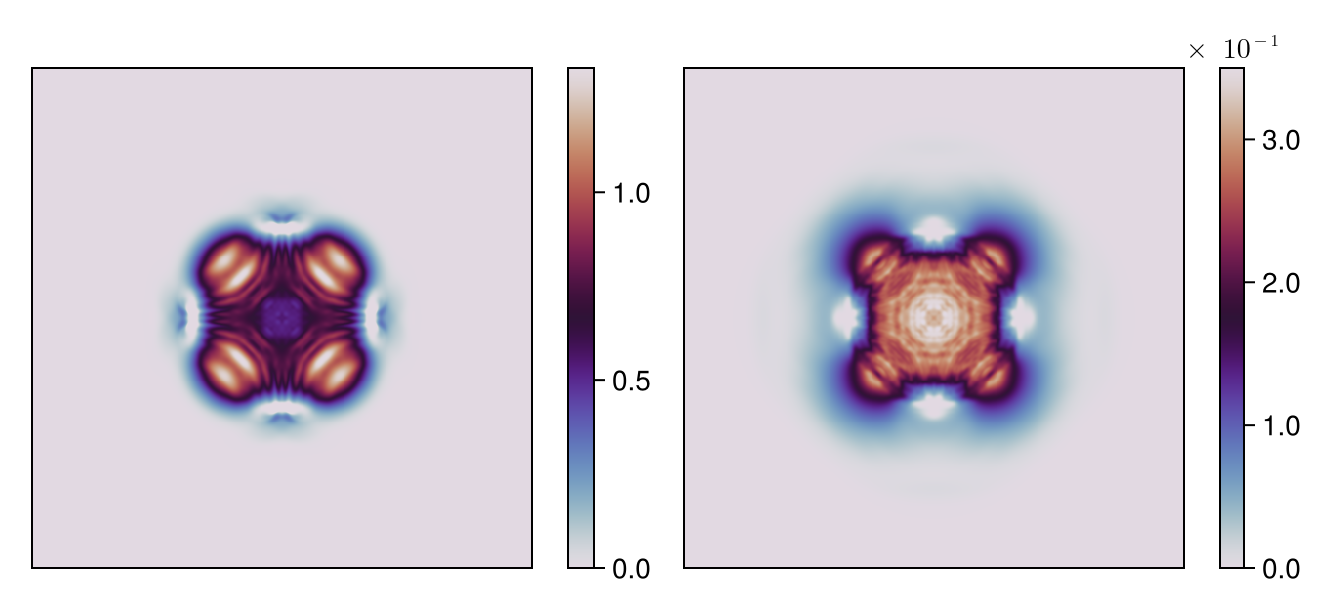

In [11]:
visualize(hcat((doe1, doe2)), real; show_colorbars = true, colormap=:twilight, height=250)

The TV-norm regularization produces smooth DOE height profiles with gentle spatial
gradients, ideal for fabrication. Heights span approximately [0, 1.5] μm, remaining
within the clamped bounds. The second DOE shows finer features that complement the
first DOE's coarser structure.

## Ring Target Optimization

For the ring target, we use basis projection to enforce cylindrical symmetry.
The basis functions are radial polynomials multiplied by a Gaussian envelope,
guaranteeing that the optimized DOE profile respects the target's rotational symmetry.
While these basis functions are not orthogonal, they provide sufficient expressiveness
for this application.

In [12]:
function radial_polynomial(D)
    function poly(x, y, p)
        r2 = x^2 + y^2
        r02 = (D/2)^2
        r2 <= r02 ? (1-(r2/r02)^p)*exp(-r2/(r02/2.5)) : 0.0
    end
    poly
end

n_basis = 12
D = 3*r0
basis_functions = make_spatial_basis(radial_polynomial(D), ns, ds, (1:n_basis))

doe1_wrap = BasisProjectionWrapper(doe1, basis_functions, zeros(n_basis))
doe2_wrap = BasisProjectionWrapper(doe2, basis_functions, zeros(n_basis))

system = source |> doe1_wrap |> prop_glass |> pb |> doe2_wrap |> prop_air;

The `BasisProjectionWrapper` constrains the DOE heights to lie in the span of the
radial basis functions. Optimization now occurs in the low-dimensional coefficient
space (12 parameters per DOE) rather than the full pixelwise space (512×512 per DOE),
naturally enforcing smoothness and cylindrical symmetry.

 56.007980 seconds (34.64 M allocations: 1.608 GiB, 3.06% gc time, 0.19% compilation time)


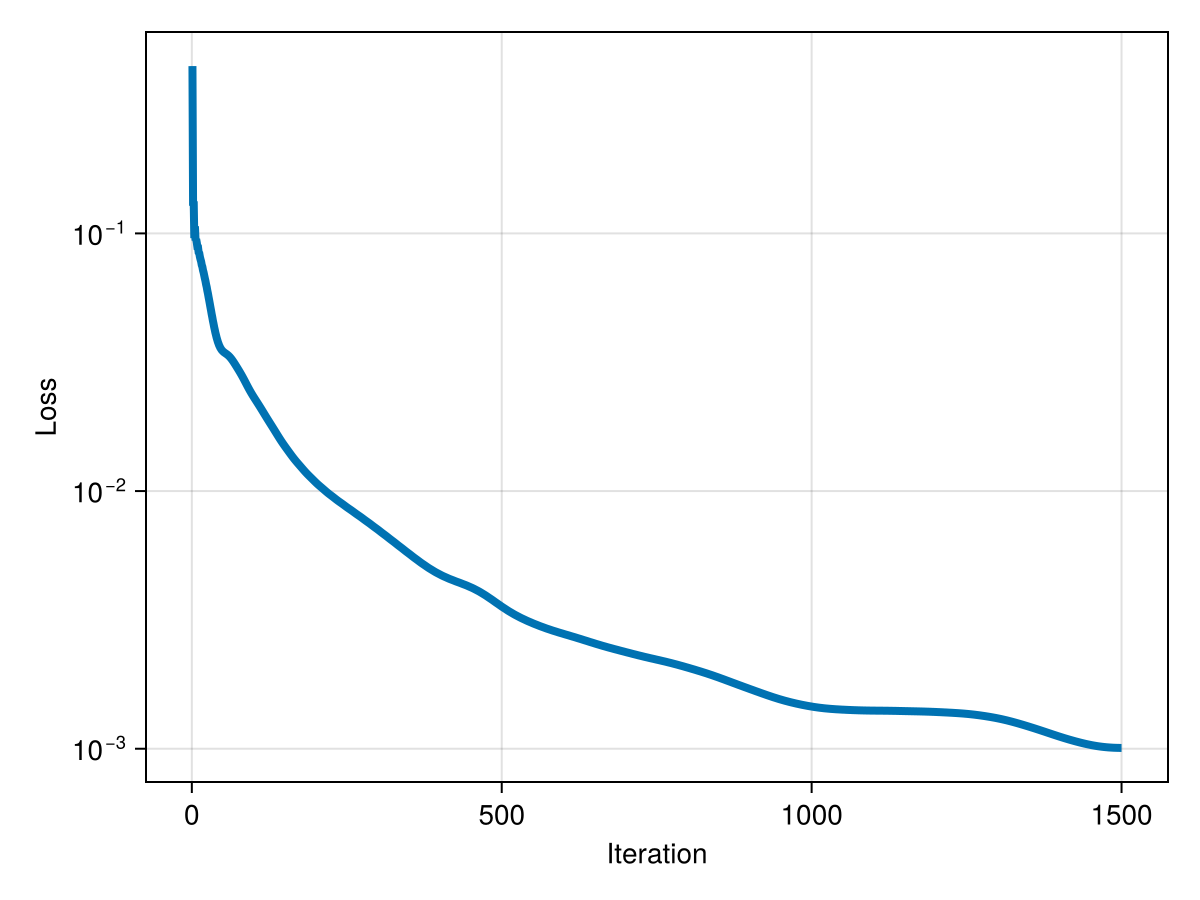

In [13]:
rule = Fista(2.0)
foreach(doe -> fill!(doe, 0), [doe1_wrap, doe2_wrap])
opt_ring = FluxOptics.setup(rule, system);

losses_ring = []
@time for iter in 1:1500
    val, grads = withgradient(loss_ring, system)
    FluxOptics.update!(opt_ring, system, grads[1])
    push!(losses_ring, val)
end

fig_loss = Figure()
ax = Makie.Axis(fig_loss[1, 1], yscale = log10, xlabel = "Iteration", ylabel = "Loss")
lines!(ax, losses_ring; linewidth = 4)
fig_loss

The optimization converges over 1500 iterations, with some oscillations characteristic
of the non-convex landscape. The reduced FISTA step size (2.0 vs 30.0 for the square)
provides more stable convergence for this geometrically constrained problem.

### Optimized result for ring target

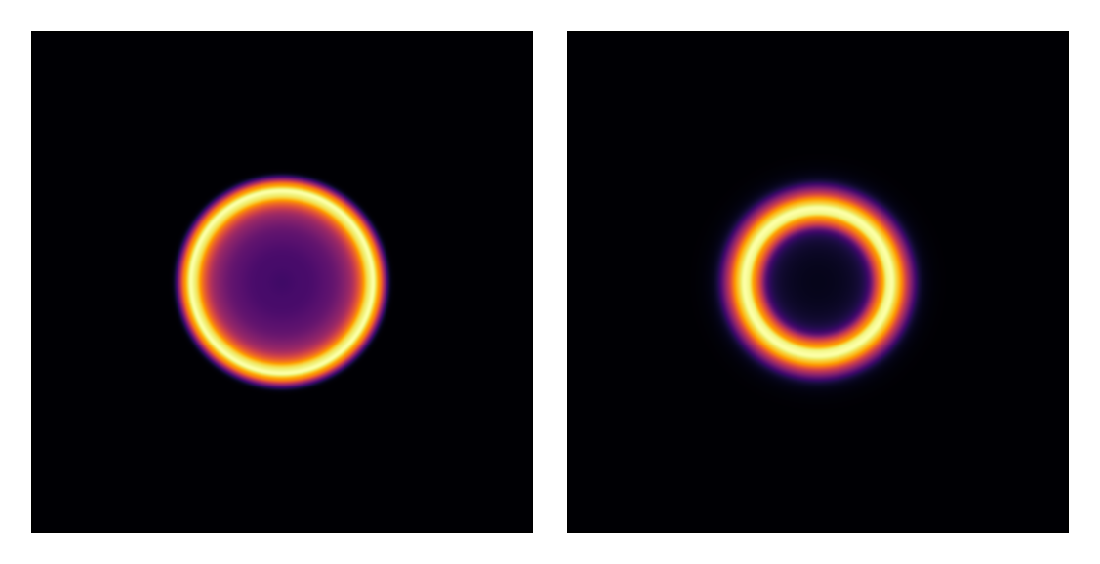

In [14]:
uf, probes = system()
u1 = probes[pb]

visualize(hcat((u1, uf)), intensity; colormap=:inferno, height=250)

### Final DOE height profiles

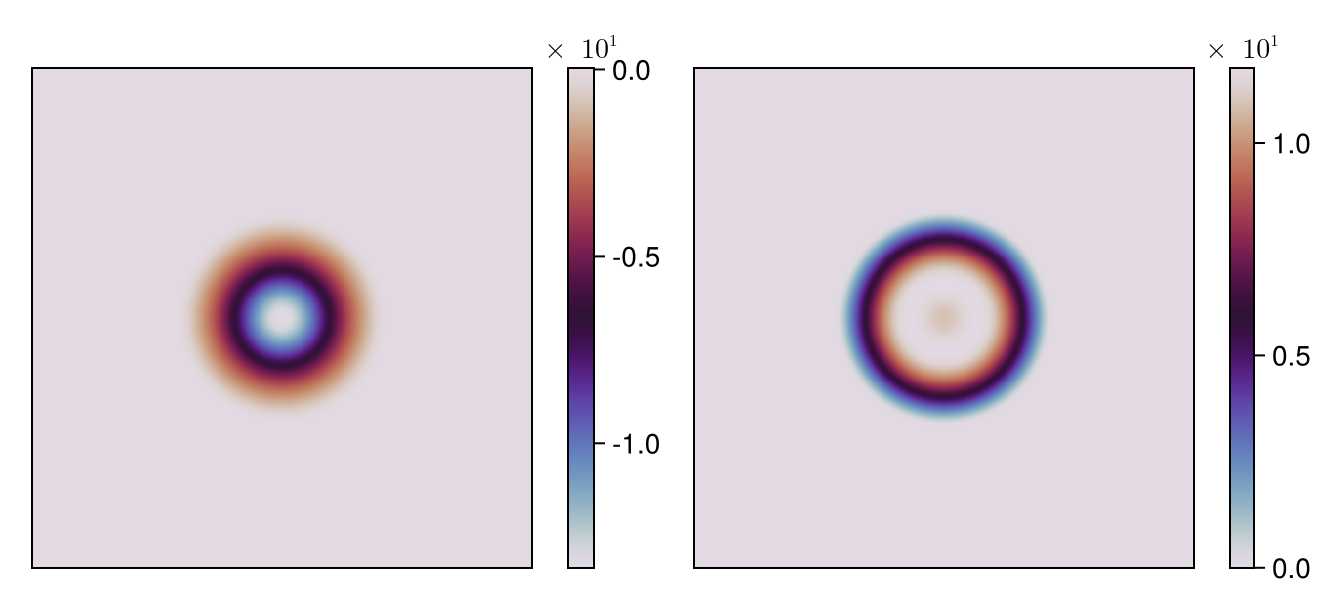

In [15]:
visualize(hcat((doe1, doe2)), real; show_colorbars=true, colormap=:twilight, height=250)

The DOE profiles exhibit perfect cylindrical symmetry enforced by the radial basis.
Heights range approximately from -14 μm to +10 μm across the two DOEs, with perfectly
smooth radial variations. The basis projection approach trades some degrees of freedom
for guaranteed fabricability and symmetry preservation.

## Key Observations

1. **Regularization strategies**: Different targets benefit from different optimization
   approaches. TV-norm works well for the square target, producing smooth profiles with
   good edge definition. Basis projection is essential for the ring target, guaranteeing
   cylindrical symmetry that would be difficult to maintain with pixelwise optimization.

2. **Step size tuning**: The FISTA step size must be adjusted based on the problem
   characteristics. Larger steps (30.0) work for TV-regularized optimization, while
   smaller steps (2.0) provide stable convergence in the basis-projected case.

3. **Fabrication constraints**: Both approaches produce fabricable DOEs. TV-norm naturally
   smooths pixelwise solutions, while basis projection inherently produces smooth profiles.
   Height ranges differ (0-1.5 μm for square, ±14/10 μm for ring) depending on the
   regularization and clamping strategy.

4. **Multimode handling**: The algorithm successfully optimizes transformations for
   105 incoherent modes simultaneously, demonstrating scalability to highly multimode
   sources. The intermediate field probe confirms that angular spectrum propagation
   remains physically reasonable throughout optimization.

5. **Non-convex optimization**: Despite the non-convex optimization landscape for both
   problems, appropriate regularization and step sizes yield good convergence.

6. **Basis choice**: The radial polynomial basis (multiplied by Gaussian envelope) provides
   sufficient expressiveness for ring shaping despite lacking orthogonality. Zernike polynomials
   or other orthogonal bases could potentially lead to faster convergence and better
   interpretability of the optimized coefficients.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*